In [1]:
import os
import re
import ast
import glob
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset, random_split 
from torch.nn.utils.rnn import pad_sequence 

import warnings
warnings.filterwarnings('ignore')

In [2]:
from datasets import load_dataset

ds = load_dataset("bdstar/Tweets-Sentiment-Analysis")

README.md: 0.00B [00:00, ?B/s]

train/DailyDialog.json:   0%|          | 0.00/18.3M [00:00<?, ?B/s]

train/negative_sentences.json:   0%|          | 0.00/191M [00:00<?, ?B/s]

train/positive_sentences.json:   0%|          | 0.00/193M [00:00<?, ?B/s]

mteb.json: 0.00B [00:00, ?B/s]

test/ChatGPT_sentiment.json:   0%|          | 0.00/267M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1646383 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/30122 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/847118 [00:00<?, ? examples/s]

In [3]:
class Config:

    data_path = None
    
    max_vocab_size = 150000 
    min_freq = 2 #2
    max_len = 50 #50

    embed_dim = 300  
    hidden_dim = 256#256 
    num_layers = 2
    dropout = 0.45
    bidirectional = True

    batch_size = 128 #128
    learning_rate = 0.00035 #0.00035 #change 
    epochs = 20

    clip_grad = 1.0
    early_stopping_patience = 5
    scheduler_factor = 0.5
    scheduler_patience = 2

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    seed = 42

    mixed_precision = torch.cuda.is_available()

    num_workers = 2 if torch.cuda.is_available() else 0
    pin_memory = torch.cuda.is_available()
    sample_size = None  # Use full dataset

config = Config()
print(config.device)

cuda


In [4]:
def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config.seed)

In [5]:
# 2. Convert the splits directly into Pandas DataFrames
print("Converting to Pandas DataFrames...")
df_train = ds['train'].to_pandas()
df_validation = ds['validation'].to_pandas()
df_test = ds['test'].to_pandas()

Converting to Pandas DataFrames...


In [6]:
# # column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
# df_train = pd.read_csv('/kaggle/input/datasets/thedevastator/tweeteval-a-multi-task-classification-benchmark/sentiment_train.csv',
#                 encoding = 'latin-1', header = 0)
# df_test = pd.read_csv('/kaggle/input/datasets/thedevastator/tweeteval-a-multi-task-classification-benchmark/sentiment_test.csv', 
#                       encoding = 'latin-1' , header = 0)
# df_validation = pd.read_csv('/kaggle/input/datasets/thedevastator/tweeteval-a-multi-task-classification-benchmark/sentiment_validation.csv',
#                        encoding = 'latin-1' , header = 0)

# df_train.head()

In [7]:
df_train.head()

,ID,text,negative,neutral,positive,label
0,1,"How are you, Mr. Ding?",0.0113,0.7568,0.2319,neutral
1,2,Covid cases are increasing fast!,0.7236,0.2287,0.0477,negative
2,3,I don't like it ever!,0.9075,0.0819,0.0106,negative
3,4,Yes That's great. I'm now happy.,0.0049,0.0109,0.9842,positive
4,5,What is this?,0.2209,0.7069,0.0723,neutral


In [8]:
df_test.head()

,ID,text,negative,neutral,positive,label
0,1,36Kr (NASDAQ: KRKR) to Innovate Content Produc...,0.003908638,0.047634073,0.9484573,positive
1,2,Baidu's Stock Poised For Growth With Rumored C...,0.0029479493,0.8842917,0.11276033,neutral
2,3,Don't Ride The ChatGPT Hype Now,0.0041330005,0.96494627,0.030920707,neutral
3,4,Google: ChatGPT's Not A Threat But Hubris Is,0.0060356855,0.98201686,0.011947508,neutral
4,5,Google: Don't Be Afraid Of ChatGPT,0.005154425,0.94161046,0.053235088,neutral


In [9]:
df_validation.head()

,ID,text,negative,neutral,positive,label
0,1,I`m not sure what you mean by 'blowin this joi...,0.1025,0.4030,0.4945,positive
1,2,i missed youtoday was the greatest day everim ...,0.0048,0.0115,0.9838,positive
2,3,it`s on again right now!! aah I love demi lovato,0.0026,0.0065,0.9910,positive
3,4,Leiiin I can play the introoo,0.0116,0.6014,0.3870,neutral
4,5,hey thereHow was your day?,0.0144,0.4149,0.5707,positive


In [10]:
df_train.rename(columns={'label': 'target'}, inplace=True)

In [11]:
df_test.rename(columns={'label': 'target'}, inplace=True)

In [12]:
df_validation.rename(columns={'label': 'target'}, inplace=True)

In [13]:
print("Converting text labels to integers...")

# 1. Define your exact mapping rules
label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2,
}

# 2. Apply the mapping to all three datasets
# (Assuming you already renamed the column to 'target'. If not, change 'target' to 'label')
df_train['target'] = df_train['target'].map(label_mapping)
df_validation['target'] = df_validation['target'].map(label_mapping)
df_test['target'] = df_test['target'].map(label_mapping)

# 3. Quick sanity check to make sure it worked
print(f"Unique values in Training targets: {df_train['target'].unique()}")

Converting text labels to integers...
Unique values in Training targets: [1 0 2]


In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1646383 entries, 0 to 1646382
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   ID        1646383 non-null  int64 
 1   text      1646383 non-null  object
 2   negative  1646383 non-null  object
 3   neutral   1646383 non-null  object
 4   positive  1646383 non-null  object
 5   target    1646383 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 75.4+ MB


In [15]:
df_train['target'].unique()

array([1, 0, 2])

In [16]:
df_train.target.value_counts()

target
2    640288
0    535426
1    470669
Name: count, dtype: int64

In [17]:
df_train.isnull().sum()

ID          0
text        0
negative    0
neutral     0
positive    0
target      0
dtype: int64

In [18]:
df_test.isnull().sum()

ID          0
text        0
negative    0
neutral     0
positive    0
target      0
dtype: int64

In [19]:
df_validation.isnull().sum()

ID          0
text        0
negative    0
neutral     0
positive    0
target      0
dtype: int64

 <div style="width: 650px; border-radius: 10px; border: 2px solid #ff0000; padding: 10px; background-color: #e8a348; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #f20707; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 5px; font-size: 24px;">Data Cleaning✨🌟</h1>
</div> 

## **Remove Html Tags and URLs<a id="Step-11"></a>**

>* In The case when we are working with textual Data then it is Essential to remove the `HTML tags` in order to take the textual Data without any formatting Hence it also essential for the `Consistency in the Data`
>* The Removing of URLs is also necessary in similar way for taking the `valuable information` and for the `Reduction of Noise in the Data`
>* `Simplified analysis:`The Removal of HTML tags and the URLs make the analysis simplified

In [20]:
import re

# Function to remove HTML tags
def remove_html_tags(text):
    clean_text = re.sub(r'<.*?>', '', text)
    return clean_text

# Function to remove URLs
def remove_urls(text):
    clean_text = re.sub(r'http\S+', '', text)
    return clean_text


## **Lower Casing and Remove ChatWords<a id="Step-12"></a>**

>* When working with Textual Data then it is necessary to convert the whole text to the lowercase Because by lowercasing the Consistency of the Data is maintained.Hence it Reduces the unique words in the vocabulary
>* The Removing of ChatWords improved the Understanding and hence it makes easier for the model to understand the content accuratly
>* It involves consistency in the language and also causes the reduction in noise

In [21]:
import string

# Function to convert text to lowercase
def convert_to_lowercase(text):
    return text.lower()

# Function to replace chat words
def replace_chat_words(text):
    chat_words = {
        "BRB": "Be right back",
        "BTW": "By the way",
        "OMG": "Oh my God/goodness",
        "TTYL": "Talk to you later",
        "OMW": "On my way",
        "SMH/SMDH": "Shaking my head/shaking my darn head",
        "LOL": "Laugh out loud",
        "TBD": "To be determined", 
        "IMHO/IMO": "In my humble opinion",
        "HMU": "Hit me up",
        "IIRC": "If I remember correctly",
        "LMK": "Let me know", 
        "OG": "Original gangsters (used for old friends)",
        "FTW": "For the win", 
        "NVM": "Nevermind",
        "OOTD": "Outfit of the day", 
        "Ngl": "Not gonna lie",
        "Rq": "real quick", 
        "Iykyk": "If you know, you know",
        "Ong": "On god (I swear)", 
        "YAAAS": "Yes!", 
        "Brt": "Be right there",
        "Sm": "So much",
        "Ig": "I guess",
        "Wya": "Where you at",
        "Istg": "I swear to god",
        "Hbu": "How about you",
        "Atm": "At the moment",
        "Asap": "As soon as possible",
        "Fyi": "For your information"
    }
    for word, expanded_form in chat_words.items():
        text = text.replace(word, expanded_form)
    return text


## **Remove Punctuation and StopWords<a id="Step-13"></a>**

>* All The punction marks are being generally shown by the command string.punctuation
>* It Involves the Improved Tokenization. Removing the punctuation marks helps in correctly identifying and separating the words present in the Data
>* It reduces the Noise of the Data
>* The Removing of stopwords helps to tooks only the important content of the Data
>* The removing of stopwords helps for the clear Analysis

In [22]:
import re
from nltk.corpus import stopwords

def clean_special_chars_and_punct(text):
    # This regex keeps letters (a-z, A-Z), numbers (0-9), spaces (\s), 
    # AND your important punctuation (\? and !)
    clean_text = re.sub(r'[^a-zA-Z0-9\s\?!]', '', text)
    return clean_text


## **Remove Witespace and Special Chararcters<a id="Step-14"></a>**

>* The whitespace generally refers to the newlines or spaces.It helps for the Reduction of Noise
>* By Removing the whitespaces and special characters the proper tokenization can be takes place
>* Removing the whitespaces from the text hepls to maintains the consistency


In [23]:
# Function to remove whitespace
def remove_whitespace(text):
    return text.strip()
def reduce_stretched_word(text):
    # 2. Reduce stretched words (e.g., "zzzzzz" -> "zz", "sleepyy" -> "sleepy")
    # This regex looks for any character (.) repeating more than twice (\1{2,}) 
    # and replaces it with just two of that character.
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return text


In [24]:
# Combine all data cleaning functions into one preprocessing function
def preprocess_text(text):
    text = remove_html_tags(text)
    text = remove_urls(text)
    text = convert_to_lowercase(text)
    text = replace_chat_words(text)
    # text = remove_punctuation(text)
    # text = remove_stopwords(text)
    text = remove_whitespace(text)
    text = reduce_stretched_word(text)
    # text = remove_special_characters(text)
    text = clean_special_chars_and_punct(text)
    return text

# Apply preprocessing function to DataFrame
df_train['text'] = df_train['text'].apply(preprocess_text)
df_test['text'] = df_test['text'].apply(preprocess_text)
df_validation['text'] = df_validation['text'].apply(preprocess_text)


<div style="width: 650px; border-radius: 10px; border: 2px solid #ff0000; padding: 10px; background-color: #e8a348; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #f20707; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 5px; font-size: 24px;">⛅Lets Generate the WordCloud⛅</h1>
</div>



In [25]:
text_sample='zzzzzzzzzzzzzzzzso I am not happy with this service!!! Right? @user #bad'
preprocess_text(text_sample)

'zzso i am not happy with this service!! right? user bad'

>* The WordCloud is used for the Visualization of the textual Data
>* It represents the most frequent words of the textual Data
>* By making the Word Cloud we can clearly visualize the frequent words of the textual  Data
>* By making word Cloud we can condense the large volume of the textual Data into a compact visualization

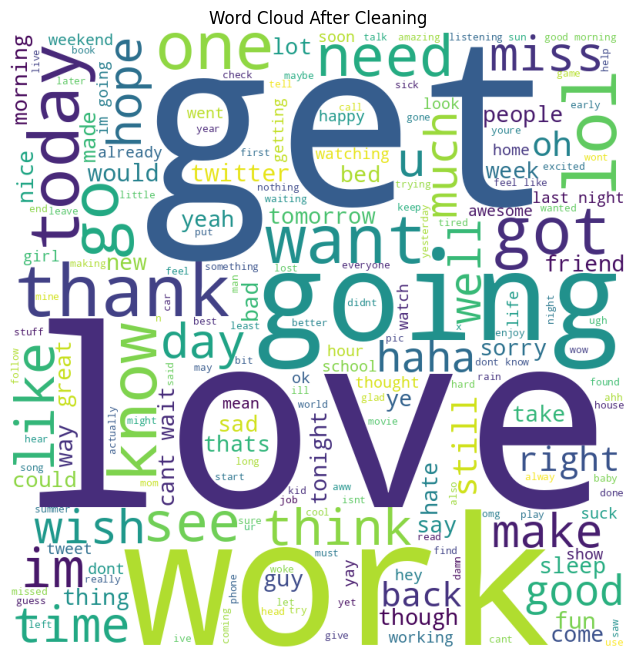

In [26]:
import pandas as pd 
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from nltk.corpus import stopwords

# Define stopwords
stop_words = set(stopwords.words('english'))

# Function to generate word cloud
def generate_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=800, 
                          background_color='white', 
                          stopwords=stop_words, 
                          min_font_size=10).generate(text)
    plt.figure(figsize=(8, 8), facecolor=None) 
    plt.imshow(wordcloud) 
    plt.axis("off") 
    plt.title(title)
    plt.show()

# Apply preprocessing function to DataFrame
# df['text'] = df['text'].apply(preprocess_text)

# Generate word cloud from cleaned text
generate_word_cloud(' '.join(df_train['text']), 'Word Cloud After Cleaning')


 <div style="width: 650px; border-radius: 10px; border: 2px solid #ff0000; padding: 10px; background-color: #e8a348; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #f20707; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 5px; font-size: 24px;">Lets Generate the Word frequency Plot💹</h1>
</div>


>* The Word Frequency plot Represents the Frequency of the words 
>* It helps to Analyze the Distribution of the Data
>* It Depict that how frequently particular word found in the Textual Data


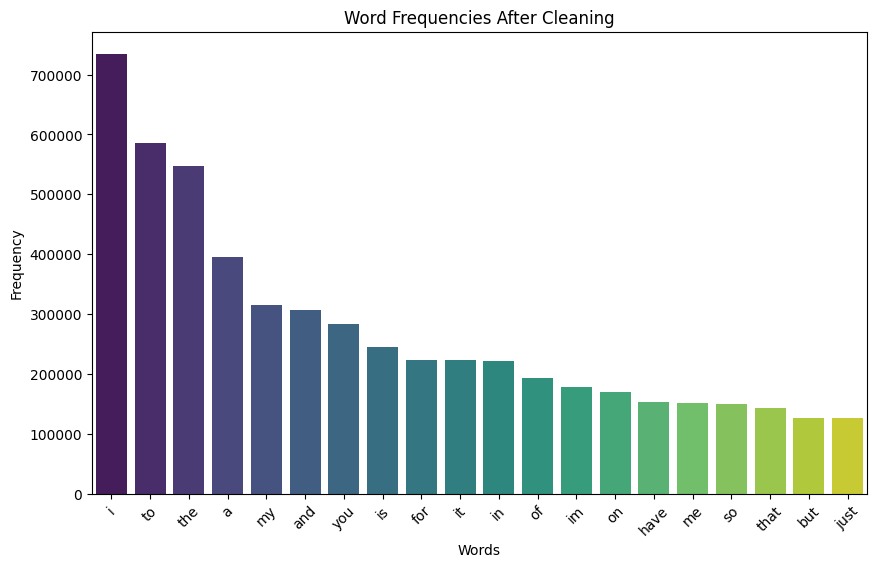

In [27]:
import nltk 
# Function to plot bar plot of word frequencies
def plot_word_frequencies(text, title):
    word_freq = nltk.FreqDist(text.split())
    common_words = word_freq.most_common(20)
    words, freqs = zip(*common_words)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(words), y=list(freqs), palette='viridis')
    plt.title(title)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()
# Step 3: Plot bar plots of word frequencies
plot_word_frequencies(' '.join(df_train['text']), 'Word Frequencies After Cleaning')
# plot_word_frequencies(' '.join(df['user']), 'User Word Frequencies After Cleaning')
# plot_word_frequencies(' '.join(df['flag']), 'Flag Word Frequencies After Cleaning')

## **WordCloud of User and Flag Column<a id="Step-17"></a>**

In [28]:
# generate_word_cloud(' '.join(df['user']), 'Word Cloud of User Column')
# generate_word_cloud(' '.join(df['flag']), 'Word Cloud of Flag Column')

In [29]:
# Lets Check Unique values after Data Cleaning
df_train['text'].unique()

array(['how are you mr ding?', 'covid cases are increasing fast!',
       'i dont like it ever!', ...,
       'zz  getting sleepyy ahah ambien  mtv wedding special was pretty good  cant wait for next part of the season 3',
       'zz goin to bed another successful day of sobriety',
       'zzso tired  good night hokies'], dtype=object)

In [30]:
from nltk.tokenize import TweetTokenizer

# Configuration:
# preserve_case=False: Converts everything to lowercase (e.g., 'HAPPY' and 'happy' become the same)
# strip_handles=True: Removes @usernames because they don't usually help determine sentiment
# reduce_len=True: Replaces 3+ repeated characters with 3 (e.g., 'waaaaay' -> 'waaay')
tknzr = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

# Apply to your dataframe
df_train['tokens'] = df_train['text'].apply(tknzr.tokenize)
df_test['tokens'] = df_test['text'].apply(tknzr.tokenize)
df_validation['tokens'] = df_validation['text'].apply(tknzr.tokenize)


# Let's see the result
print(df_train['tokens'].head())
print()
print(df_test['tokens'].head())
print()
print(df_validation['tokens'].head())


0                [how, are, you, mr, ding, ?]
1    [covid, cases, are, increasing, fast, !]
2                [i, dont, like, it, ever, !]
3         [yes, thats, great, im, now, happy]
4                         [what, is, this, ?]
Name: tokens, dtype: object

0    [36kr, nasdaq, krkr, to, innovate, content, pr...
1    [baidus, stock, poised, for, growth, with, rum...
2                [dont, ride, the, chatgpt, hype, now]
3    [google, chatgpts, not, a, threat, but, hubris...
4              [google, dont, be, afraid, of, chatgpt]
Name: tokens, dtype: object

0    [im, not, sure, what, you, mean, by, blowin, t...
1    [i, missed, youtoday, was, the, greatest, day,...
2    [its, on, again, right, now, !, !, aah, i, lov...
3                   [leiin, i, can, play, the, introo]
4                   [hey, therehow, was, your, day, ?]
Name: tokens, dtype: object


In [31]:
print("Rows:", len(df_train))
print("Example tokens:", df_train['tokens'].iloc[0])

Rows: 1646383
Example tokens: ['how', 'are', 'you', 'mr', 'ding', '?']


In [32]:
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split

print("3. Building Vocabulary...")
# all_tokens = [token for tokens in df_train['tokens'] for token in tokens]
# Combine tokens from all three datasets to build a massive vocabulary
all_tokens = (
    [token for tokens in df_train['tokens'] for token in tokens] +
    [token for tokens in df_validation['tokens'] for token in tokens] +
    [token for tokens in df_test['tokens'] for token in tokens]
)
word_counts = Counter(all_tokens)

vocab_words = [
    word for word, count in word_counts.most_common(config.max_vocab_size-2)
    if count >= config.min_freq
]

word2idx = {word: i+2 for i, word in enumerate(vocab_words)}
word2idx['<PAD>'] = 0
word2idx['<UNK>'] = 1
idx2word = {i: w for w, i in word2idx.items()}

vocab_size = len(word2idx)
print(f"Final Vocabulary Size: {vocab_size}")

# --- STEP 4: Your Conversion Code + Padding ---

print("4. Converting text to sequences...")
def text_to_indices(tokens):
    return [word2idx.get(token, 1) for token in tokens][:config.max_len] # Added max_len slicing

# Apply to all three datasets
df_train['encoded_tokens'] = df_train['tokens'].apply(text_to_indices)
df_validation['encoded_tokens'] = df_validation['tokens'].apply(text_to_indices)
df_test['encoded_tokens'] = df_test['tokens'].apply(text_to_indices)

# Convert to PyTorch tensors and Pad
def prepare_tensors(df):
    X_indices = [torch.tensor(tokens) for tokens in df['encoded_tokens']]
    X_padded = pad_sequence(X_indices, batch_first=True, padding_value=word2idx['<PAD>'])
    y_tensor = torch.tensor(df['target'].values, dtype=torch.long)
    return X_padded, y_tensor
    
X_train, y_train = prepare_tensors(df_train)
X_val, y_val = prepare_tensors(df_validation)
X_test, y_test = prepare_tensors(df_test)

print("5. Loading GloVe Embeddings...")
# Make sure the path matches the GloVe dataset you added in Kaggle!
glove_path = '/kaggle/input/datasets/wiseyy/glove6b300dtxt/glove.6B.300d.txt' 

embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in tqdm(f, desc="Reading GloVe"):
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print("6. Creating Embedding Matrix for our Vocab...")
embedding_matrix = np.zeros((vocab_size, config.embed_dim))
hits, misses = 0, 0

# FIXED: Iterating over word2idx instead of vocab_words
for word, i in word2idx.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        if i != 0: # We want to keep the padding token <PAD> at index 0 as all zeros
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(config.embed_dim, ))
        misses += 1

print(f"GloVe coverage: {hits/(hits+misses):.2%} words found.")
embedding_matrix_tensor = torch.FloatTensor(embedding_matrix)

# # Split into Train/Test datasets
# X_train, X_test, y_train, y_test = train_test_split(X_padded, y_tensor, test_size=0.2, random_state=config.seed)
# train_dataset = TensorDataset(X_train, y_train)
# train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)

print("7. Creating DataLoaders...")
# We use the explicit splits instead of train_test_split
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)

print("Ready for training loop!")

3. Building Vocabulary...
Final Vocabulary Size: 150000
4. Converting text to sequences...
5. Loading GloVe Embeddings...


Reading GloVe: 400000it [00:30, 13059.06it/s]


6. Creating Embedding Matrix for our Vocab...
GloVe coverage: 44.90% words found.
7. Creating DataLoaders...
Ready for training loop!


In [33]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence

# 1. Define the Dataset Class
class TweetDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        
        # CRITICAL FIX: Sentiment140 labels are 0 (neg) and 4 (pos). 
        # PyTorch Binary Cross Entropy requires 0 and 1.
        self.labels = labels #[1 if label == 4 else 0 for label in labels]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Convert the list of integers to a tensor
        tweet = torch.tensor(self.sequences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return tweet, label

# 2. Define the Collate Function for Dynamic Padding
def collate_fn(batch):
    # Separate tweets and labels
    tweets, labels = zip(*batch)
    
    # Pad the tweets dynamically for this batch only
    # batch_first=True makes the shape [batch_size, max_seq_len_in_batch]
    tweets_padded = pad_sequence(tweets, batch_first=True, padding_value=0)
    
    # Convert labels tuple to a single tensor
    labels_tensor = torch.stack(labels)
    
    return tweets_padded, labels_tensor

# 3. Instantiate the Dataset
# # We pass the raw lists of encoded tokens, NOT pre-padded sequences
# dataset = TweetDataset(df['encoded_tokens'].values, df['target'].values)
train_dataset = TweetDataset(df_train['encoded_tokens'].values, df_train['target'].values)
val_dataset = TweetDataset(df_validation['encoded_tokens'].values, df_validation['target'].values)
test_dataset = TweetDataset(df_test['encoded_tokens'].values, df_test['target'].values)

print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

# # 4. Split the Dataset
# train_size = int(0.8 * len(dataset))
# val_size = int(0.1 * len(dataset))
# test_size = len(dataset) - train_size - val_size

# train_dataset, val_dataset, test_dataset = random_split(
#     dataset, [train_size, val_size, test_size]
# )

# print(f"Dataset split: Train={train_size}, Val={val_size}, Test={test_size}")

# 5. Create DataLoaders
# Only the training loader needs shuffle=True
train_loader = DataLoader(
    train_dataset, 
    batch_size=config.batch_size, 
    shuffle=True, 
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=config.batch_size, 
    shuffle=False, 
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=config.batch_size, 
    shuffle=False, 
    collate_fn=collate_fn
)

print("DataLoaders are ready!")

Dataset sizes: Train=1646383, Val=30122, Test=847118
DataLoaders are ready!


In [34]:
import torch
import torch.nn as nn

class MultiHeadAttentionLayer(nn.Module):
    def __init__(self, hidden_dim, num_heads=8):
        super().__init__()
        # hidden_dim must be divisible by num_heads
        self.mha = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)

    def forward(self, lstm_outputs):
        # MHA expects (query, key, value)
        attn_output, _ = self.mha(lstm_outputs, lstm_outputs, lstm_outputs)
        
        # We take the mean across the sequence dimension to get a single vector representation
        return torch.max(attn_output, dim=1)[0]


class SentimentModel(nn.Module):
    def __init__(self, vocab_size, pretrained_embeddings, config):
        super().__init__()
        
        # 0. Embedding Layer
        self.embedding = nn.Embedding.from_pretrained(
            pretrained_embeddings, 
            freeze=False,   
            padding_idx=0   
        )
        
        # 1. CNN Layer: Extracts local patterns (n-grams)
        self.cnn = nn.Conv1d(
            in_channels=config.embed_dim, 
            out_channels=config.embed_dim, 
            kernel_size=3, 
            padding=1
        )
        self.relu = nn.ReLU()
        
        # CNN Dropout to prevent early overfitting
        self.cnn_dropout = nn.Dropout(0.3)  
        
        # 2. Bi-LSTM Layer
        self.lstm = nn.LSTM(
            config.embed_dim, config.hidden_dim, num_layers=config.num_layers,
            batch_first=True, bidirectional=True, dropout=0.3 if config.num_layers > 1 else 0
        )
        
        
        # 3. Multi-Head Attention
        # BiLSTM outputs hidden_dim * 2, so our attention needs to handle that dimension
        lstm_out_dim = config.hidden_dim * 2
        self.attention = MultiHeadAttentionLayer(lstm_out_dim, num_heads=8)
        
        # ==========================================================
        # 4. UPGRADED CLASSIFICATION HEAD (The "Stronger Algo")
        # ==========================================================
        self.fc = nn.Sequential(
            # First dense transformation
            nn.Linear(lstm_out_dim, lstm_out_dim),
            nn.LayerNorm(lstm_out_dim),  # Stabilizes activations
            nn.GELU(),                   # Smoother non-linearity than ReLU
            nn.Dropout(0.5),             # Heavy dropout before final layers
            
            # Second dense transformation (funneling down)
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.LayerNorm(lstm_out_dim // 2),
            nn.GELU(),
            nn.Dropout(0.3),
            
            # Final output node
            # nn.Linear(lstm_out_dim // 2, 1)
            # Multiclass Classification. 
            nn.Linear(lstm_out_dim // 2, 3) 
        )

    def forward(self, x):
        # Embeddings: [batch, seq_len] -> [batch, seq_len, embed_dim]
        x = self.embedding(x)
        
        # CNN Prep: [batch, embed_dim, seq_len]
        x = x.transpose(1, 2)
        x = self.relu(self.cnn(x)) 
        x = self.cnn_dropout(x)
        
        # Transpose back for LSTM: [batch, seq_len, embed_dim]
        x = x.transpose(1, 2)
        
        # LSTM
        lstm_out, _ = self.lstm(x)
        
        # Attention: Returns [batch, hidden_dim * 2]
        x = self.attention(lstm_out)
        
        # Upgraded Output Logits
        x = self.fc(x)
        
        # return x.squeeze()
        return x  # Just return x, no squeeze needed for multiclass

# Example of how to instantiate it now:
# model = SentimentModel(vocab_size, embedding_matrix_tensor, config)

In [35]:
import torch
import torch.optim as optim
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

# # Calculate weights based on your training labels
# class_weights = compute_class_weight(
#     class_weight='balanced', 
#     classes=np.unique(df_train['target']), 
#     y=df_train['target']
# )
# weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(config.device)

# ==========================================
# 1. Model Instantiation
# ==========================================
# FIX: Added 'config' to the arguments!
model = SentimentModel(
    vocab_size=len(word2idx), 
    pretrained_embeddings=embedding_matrix_tensor,
    config=config  
).to(config.device)

# ==========================================
# 2. Loss & Optimizer
# ==========================================
# Standard BCE (Logits means it expects raw numbers, NO sigmoid in your model)
# criterion = nn.BCEWithLogitsLoss()
criterion = nn.CrossEntropyLoss()

# AdamW is the gold standard for NLP with heavy regularization (weight_decay)
optimizer = optim.AdamW(
    model.parameters(), 
    lr=config.learning_rate, # OneCycleLR actually controls this, so just pass the max_lr here
    weight_decay=0.04     
)

# ==========================================
# 3. Learning Rate Scheduler
# ==========================================
# This will start the LR at (learning_rate/10), peak at (learning_rate) at 20% of training, 
# and then decay down to (learning_rate/100).
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config.learning_rate, 
    epochs=config.epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.2,            
    anneal_strategy='cos',
    div_factor=15.0,          
    final_div_factor=100.0    
)

# ==========================================
# 4. Mixed Precision
# ==========================================
# Updated to modern PyTorch 2.0+ syntax to avoid warnings
if config.mixed_precision:
    scaler = torch.amp.GradScaler('cuda') 
else:
    scaler = None
    
print("Training dependencies initialized!")

Training dependencies initialized!


In [36]:
import torch
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def train_epoch(model, loader, optimizer, criterion, scheduler, device, clip_grad, scaler=None):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for texts, labels in pbar:
        texts = texts.to(device)
        # labels = labels.to(device).float() 
        labels = labels.to(device).long()
        
        optimizer.zero_grad()

        if scaler:
            # Modern PyTorch 2.0+ Autocast syntax
            with torch.autocast(device_type=device.type if device.type != 'mps' else 'cpu'):
                outputs = model(texts)
                
                # SAFETY FIX: Ensure 1D shapes so BCEWithLogitsLoss doesn't crash on batch_size=1
                # outputs = outputs.view(-1)
                # labels = labels.view(-1)
                
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            
            # AMP + SCHEDULER FIX: Only step scheduler if the optimizer actually stepped
            scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            
            if scale == scaler.get_scale():
                scheduler.step()
                
        else:
            outputs = model(texts)
            
            # # SAFETY FIX
            # outputs = outputs.view(-1)
            # labels = labels.view(-1)
            
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()
            scheduler.step()

        # Statistics
        total_loss += loss.item() * texts.size(0)
        
        # Logits >= 0.0 is the same as Sigmoid(Logits) >= 0.5
        # preds = (outputs >= 0.0).float() 
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += texts.size(0)

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}', 
            'acc': f'{correct/total:.4f}'
        })

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for texts, labels in tqdm(loader, desc="Evaluating", leave=False):
            texts = texts.to(device)
            # labels = labels.to(device).float()
            labels = labels.to(device).long()
            
            # Modern PyTorch 2.0+ Autocast for faster evaluation too!
            with torch.autocast(device_type=device.type if device.type != 'mps' else 'cpu'):
                outputs = model(texts)
                
                # SAFETY FIX
                # outputs = outputs.view(-1)
                # labels = labels.view(-1)
                
                loss = criterion(outputs, labels)
            
            total_loss += loss.item() * texts.size(0)
            
            # Convert logits to probabilities
            # probs = torch.sigmoid(outputs).cpu().numpy() 
            # preds = (probs >= 0.5).astype(int)
            probs = torch.softmax(outputs, dim=1).cpu().numpy() # Add this
            preds = np.argmax(probs, axis=1) # Add this: Get index of max probability
            
            # .tolist() is safer for extending lists than raw numpy arrays
            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    
    # Calculate professional metrics
    # precision, recall, f1, _ = precision_recall_fscore_support(
    #     all_labels, all_preds, average='binary', zero_division=0
    # )
    precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, 
    average='macro', # CHANGE 'binary' to 'macro'
    zero_division=0
    )
    
    return avg_loss, acc, precision, recall, f1, all_preds, all_labels, all_probs

In [37]:
import torch
import numpy as np

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001, verbose=True, path='best_model.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.path = path
        
        self.counter = 0
        self.best_loss = np.inf # Start at infinity
        self.early_stop = False

    def __call__(self, val_loss, model):
        # If loss is NaN, stop immediately to save time/compute
        if np.isnan(val_loss):
            if self.verbose: print("EarlyStopping: Validation loss is NaN. Stopping...")
            self.early_stop = True
            return True

        if val_loss < self.best_loss - self.min_delta:
            # Significant improvement found
            if self.verbose:
                print(f"EarlyStopping: Validation loss improved ({self.best_loss:.6f} --> {val_loss:.6f}). Saving model...")
            
            self.save_checkpoint(model)
            self.best_loss = val_loss
            self.counter = 0
        else:
            # No significant improvement
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping: No improvement for {self.counter}/{self.patience} epochs.")
            
            if self.counter >= self.patience:
                self.early_stop = True
                
        return self.early_stop

    def save_checkpoint(self, model):
        '''Saves model when validation loss decreases.'''
        torch.save(model.state_dict(), self.path)

In [38]:
import torch

# 1. Initialization
print("\n" + "="*50)
print("Initialising Training Components...")
print("="*50)

# ==========================================
# FIX: Added 'pretrained_embeddings=embedding_matrix_tensor'
# ==========================================

# Initialize Early Stopping
early_stopping = EarlyStopping(
    patience=config.early_stopping_patience, 
    path='best_model_weights.pt',
    verbose=True
)

# Initialize History Tracking
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'val_precision': [], 'val_recall': [], 'val_f1': []
}

best_val_acc = 0
best_epoch = 0

# 2. Starting the Loop
print("\n" + "="*50)
print("Starting Training...")
print("="*50)

for epoch in range(1, config.epochs + 1):
    print(f"\n{'='*40}")
    print(f"Epoch {epoch}/{config.epochs}")
    print(f"{'='*40}")
    
    # Train - Note: OneCycleLR needs scheduler.step() inside train_epoch
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, criterion, scheduler,
        config.device, config.clip_grad, scaler
    )
    
    # Validate
    val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = evaluate(
        model, val_loader, criterion, config.device
    )
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_prec)
    history['val_recall'].append(val_rec)
    history['val_f1'].append(val_f1)
    
    # Print results
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Precision: {val_prec:.4f} | Recall: {val_rec:.4f} | F1: {val_f1:.4f}")
    
    # Checkpoint logic for high-accuracy targets
    if val_acc > 0.95:
        print(f" 🎉 Target achieved! Validation accuracy > 95%")
    
    # Save best model based on Accuracy (for your tracking)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        # Save a full checkpoint (not just weights) for easy resumption
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'word2idx': word2idx,
            'config': config
        }, 'checkpoint_best_acc.pt')
        print(f" ⭐ New best accuracy! Saved checkpoint.")
    
    # Early stopping based on Loss (best for generalization)
    # We pass the model so it can save the 'best_model_weights.pt' automatically
    if early_stopping(val_loss, model):
        print(f"\n 🛑 Early stopping triggered at epoch {epoch}")
        break
    
    # Final stop condition for speed
    if val_acc > 0.97: 
        print(f"\n 🚀 Reached elite accuracy! Stopping early.")
        break

# 3. Post-Training: Load the best weights found by EarlyStopping
try:
    model.load_state_dict(torch.load('best_model_weights.pt'))
    print(f"\nTraining completed! Loaded best weights from epoch {best_epoch}.")
except FileNotFoundError:
    print("\nTraining completed! (No better weights were saved by early stopping).")


Initialising Training Components...

Starting Training...

Epoch 1/20


Training:   0%|          | 0/12863 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/236 [00:00<?, ?it/s]


Train Loss: 0.5994 | Train Acc: 0.7443
Val Loss: 0.5303 | Val Acc: 0.7843
Precision: 0.7737 | Recall: 0.7709 | F1: 0.7720
 ⭐ New best accuracy! Saved checkpoint.
EarlyStopping: Validation loss improved (inf --> 0.530283). Saving model...

Epoch 2/20


Training:   0%|          | 0/12863 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/236 [00:00<?, ?it/s]


Train Loss: 0.1272 | Train Acc: 0.9513
Val Loss: 0.3603 | Val Acc: 0.8983
Precision: 0.8919 | Recall: 0.8923 | F1: 0.8921
 ⭐ New best accuracy! Saved checkpoint.
EarlyStopping: No improvement for 4/5 epochs.

Epoch 15/20


Training:   0%|          | 0/12863 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/236 [00:00<?, ?it/s]


Train Loss: 0.1117 | Train Acc: 0.9573
Val Loss: 0.3679 | Val Acc: 0.9007
Precision: 0.8943 | Recall: 0.8952 | F1: 0.8947
 ⭐ New best accuracy! Saved checkpoint.
EarlyStopping: No improvement for 5/5 epochs.

 🛑 Early stopping triggered at epoch 15

Training completed! Loaded best weights from epoch 15.


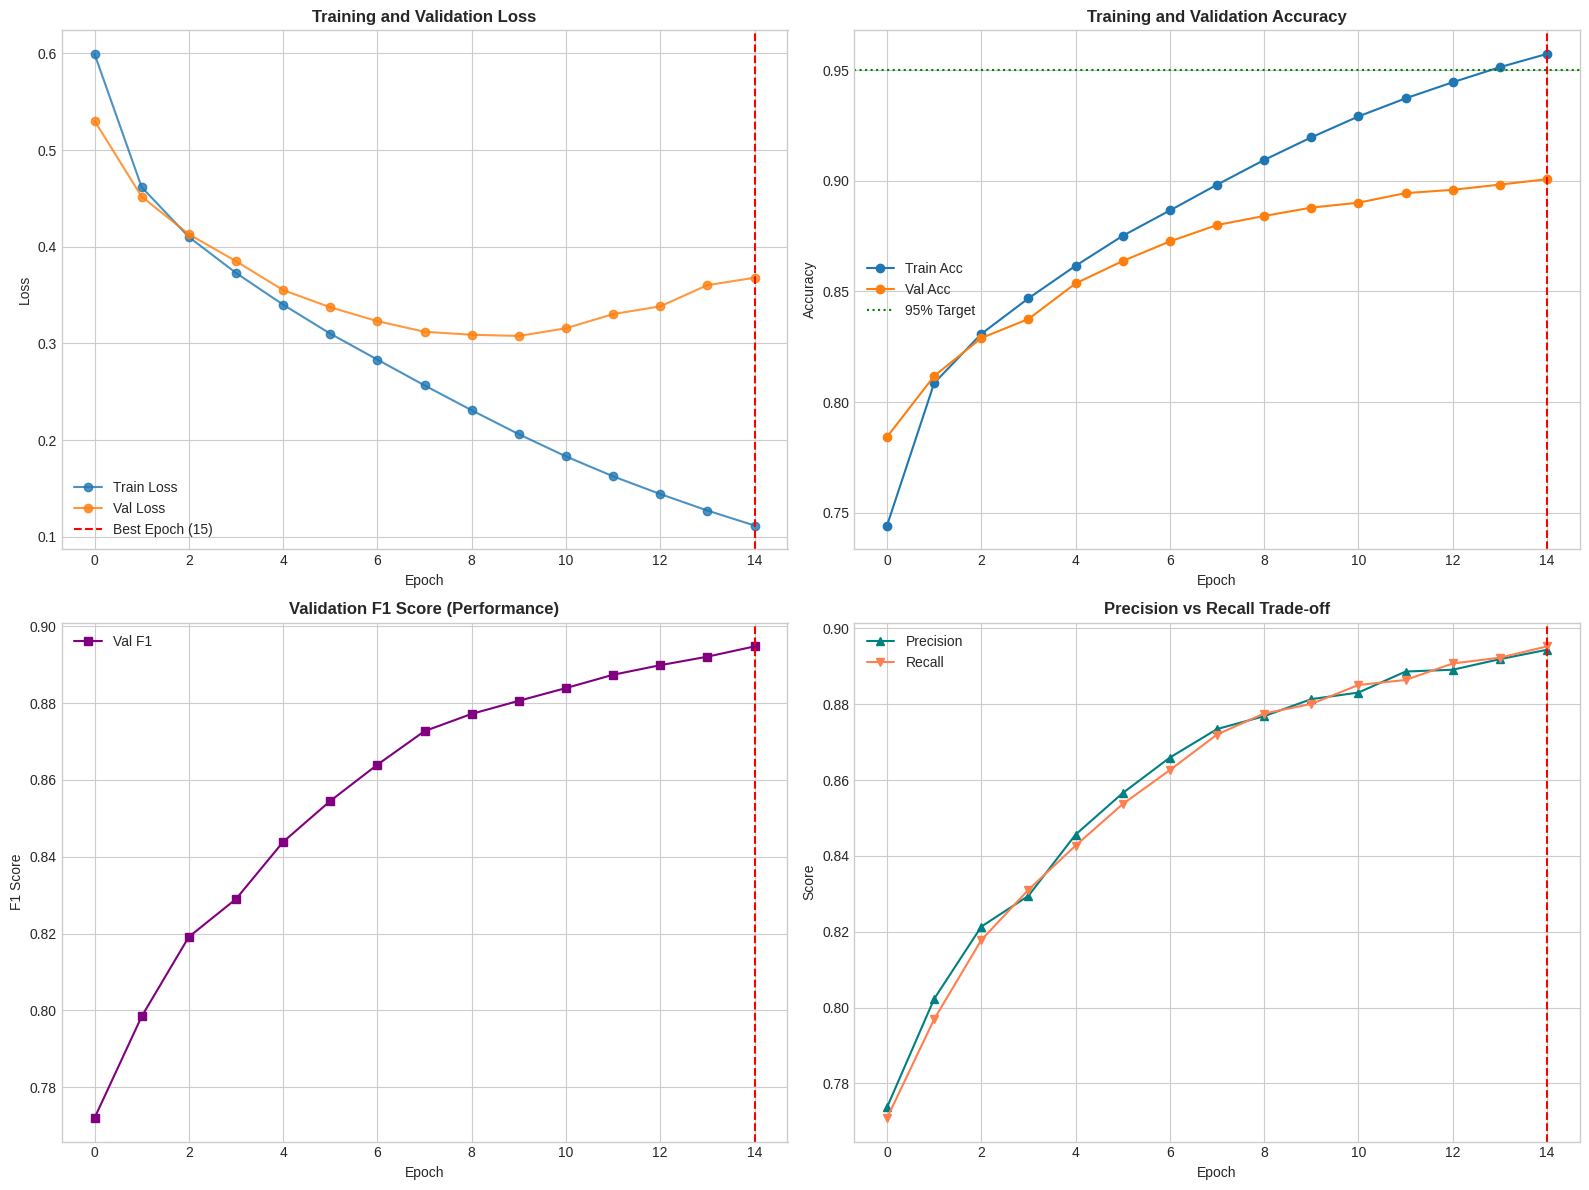

In [39]:
import matplotlib.pyplot as plt

if len(history['train_loss']) > 0:
    # Use a clean style for better readability
    plt.style.use('seaborn-v0_8-whitegrid') 
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Adjust best_epoch for 0-indexing in plots
    best_idx = best_epoch - 1 

    # 1. Loss curves
    axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o', alpha=0.8)
    axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='o', alpha=0.8)
    if best_epoch > 0:
        axes[0, 0].axvline(x=best_idx, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # 2. Accuracy curves
    axes[0, 1].plot(history['train_acc'], label='Train Acc', marker='o', color='tab:blue')
    axes[0, 1].plot(history['val_acc'], label='Val Acc', marker='o', color='tab:orange')
    if best_epoch > 0:
        axes[0, 1].axvline(x=best_idx, color='red', linestyle='--')
    axes[0, 1].axhline(y=0.95, color='green', linestyle=':', label='95% Target')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Training and Validation Accuracy', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # 3. F1 Score
    axes[1, 0].plot(history['val_f1'], label='Val F1', marker='s', color='purple')
    if best_epoch > 0:
        axes[1, 0].axvline(x=best_idx, color='red', linestyle='--')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].set_title('Validation F1 Score (Performance)', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # 4. Precision & Recall
    axes[1, 1].plot(history['val_precision'], label='Precision', marker='^', color='teal')
    axes[1, 1].plot(history['val_recall'], label='Recall', marker='v', color='coral')
    if best_epoch > 0:
        axes[1, 1].axvline(x=best_idx, color='red', linestyle='--')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_title('Precision vs Recall Trade-off', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    
    # CRITICAL: Save BEFORE showing
    plt.savefig('training_performance_curves.png', dpi=300)
    plt.show()
else:
    print("History is empty. No plots to generate.")


Evaluating on Test Set


Evaluating:   0%|          | 0/6619 [00:00<?, ?it/s]


#################### TEST RESULTS ####################
Loss:      1.2055
Accuracy:  0.6739
Precision: 0.7013
Recall:    0.6544
F1-Score:  0.6643

📊 Accuracy: 67.39%. Need 27.61% more for target.

Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.59      0.63    194061
     Neutral       0.61      0.81      0.70    358516
    Positive       0.81      0.56      0.66    294541

    accuracy                           0.67    847118
   macro avg       0.70      0.65      0.66    847118
weighted avg       0.70      0.67      0.67    847118



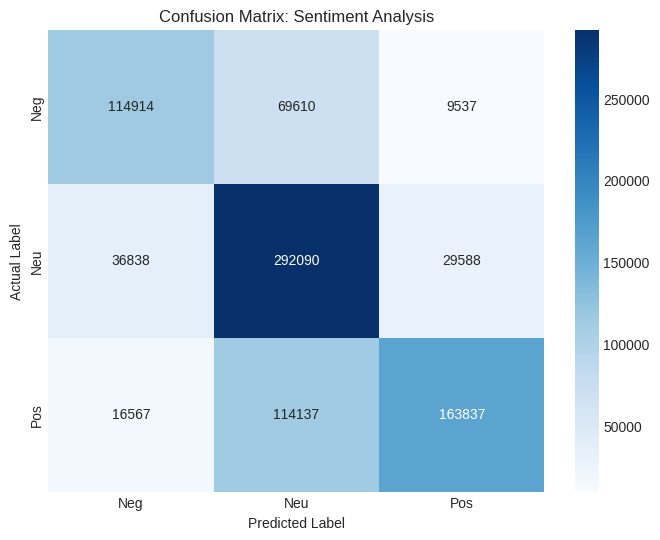

In [40]:
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("\n" + "="*50)
print("Evaluating on Test Set")
print("="*50)

# Load best model
if os.path.exists('best_model.pt'):
    # weights_only=True is secure but picky about custom classes. 
    # If it fails, you can set it to False since this is your own file.
    try:
        checkpoint = torch.load('best_model.pt', map_location=config.device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ Loaded best model from epoch {checkpoint['epoch']} (Val Acc: {checkpoint['val_acc']:.4f})")
    except Exception as e:
        print(f"⚠️ Error loading checkpoint: {e}")
        # Fallback to loading the raw weights if you used the EarlyStopping class save path
        if os.path.exists('best_model_weights.pt'):
            model.load_state_dict(torch.load('best_model_weights.pt'))
            print("✅ Loaded raw weights from best_model_weights.pt")

# Perform Evaluation
test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, config.device
)

# 1. Print Numerical Results
print(f"\n{'#'*20} TEST RESULTS {'#'*20}")
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-Score:  {test_f1:.4f}")

if test_acc >= 0.95:
    print("\n🎉 SUCCESS! Achieved 95%+ test accuracy!")
else:
    print(f"\n📊 Accuracy: {test_acc:.2%}. Need {0.95-test_acc:.2%} more for target.")

# 2. Detailed Classification Report
print("\nClassification Report:")
# print(classification_report(test_labels, test_preds, target_names=['Negative', 'Positive']))
print(classification_report(test_labels, test_preds, target_names=['Negative', 'Neutral', 'Positive']))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
labels = ['Neg', 'Neu', 'Pos'] # Added Neu
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title('Confusion Matrix: Sentiment Analysis')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

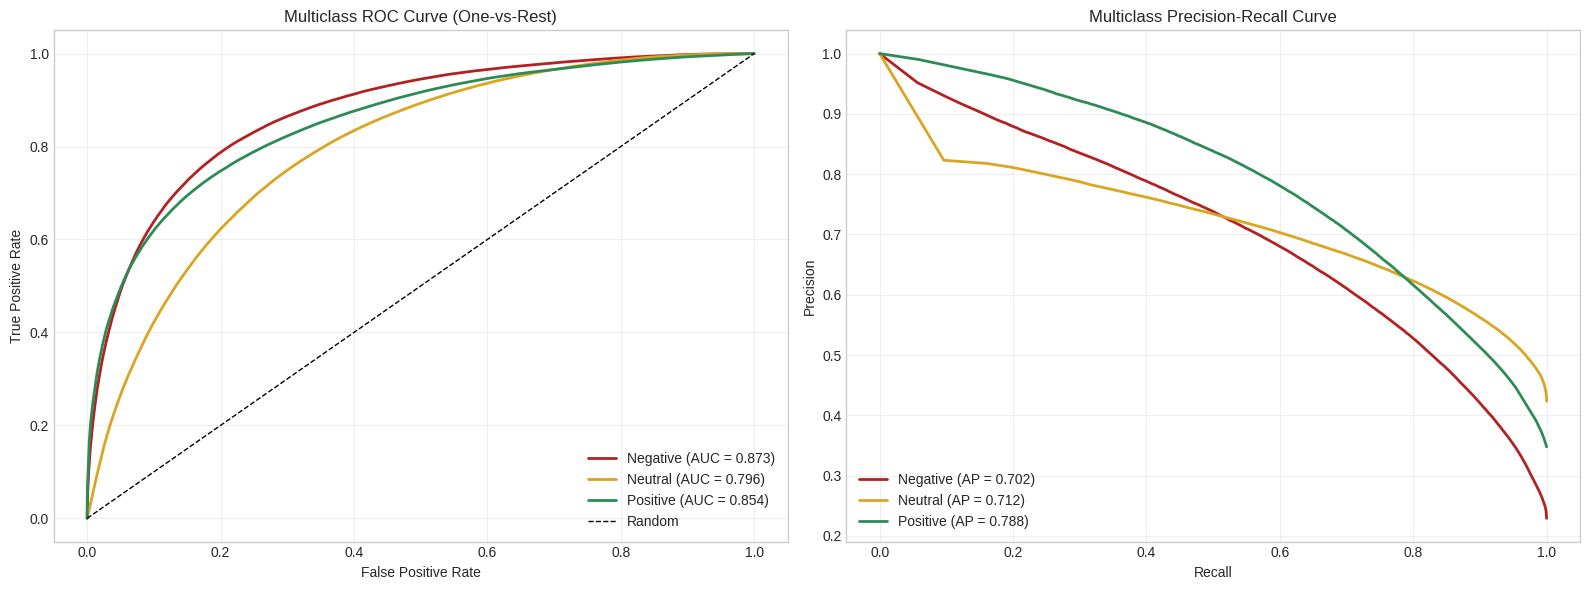

✅ Mean ROC-AUC: 0.8410
✅ Mean Average Precision: 0.7337


In [41]:
#for Multiclass classification [0,1,2]
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# 0. Setup for Multiclass
n_classes = 3
class_names = ['Negative', 'Neutral', 'Positive']
# Binarize labels for One-vs-Rest calculation
y_test_binarized = label_binarize(test_labels, classes=[0, 1, 2])
# Ensure test_probs is a numpy array of shape (n_samples, 3)
probs_array = np.array(test_probs) 

# Storage for metrics
fpr, tpr, roc_auc = {}, {}, {}
precision_vals, recall_vals, avg_precision = {}, {}, {}

# 1. Calculate metrics for each class
for i in range(n_classes):
    # ROC
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], probs_array[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
    # PR
    precision_vals[i], recall_vals[i], _ = precision_recall_curve(y_test_binarized[:, i], probs_array[:, i])
    avg_precision[i] = average_precision_score(y_test_binarized[:, i], probs_array[:, i])

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['firebrick', 'goldenrod', 'seagreen']

# ROC Curve Plotting

for i, color in zip(range(n_classes), colors):
    ax1.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax1.set_title('Multiclass ROC Curve (One-vs-Rest)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Precision-Recall Plotting
for i, color in zip(range(n_classes), colors):
    ax2.plot(recall_vals[i], precision_vals[i], color=color, lw=2,
             label=f'{class_names[i]} (AP = {avg_precision[i]:.3f})')

ax2.set_title('Multiclass Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('multiclass_evaluation_curves.png', dpi=300)
plt.show()

# Print average results
print(f"✅ Mean ROC-AUC: {np.mean(list(roc_auc.values())):.4f}")
print(f"✅ Mean Average Precision: {np.mean(list(avg_precision.values())):.4f}")


DETAILED CLASSIFICATION REPORT (3-CLASS)
              precision    recall  f1-score   support

    Negative       0.68      0.59      0.63    194061
     Neutral       0.61      0.81      0.70    358516
    Positive       0.81      0.56      0.66    294541

    accuracy                           0.67    847118
   macro avg       0.70      0.65      0.66    847118
weighted avg       0.70      0.67      0.67    847118



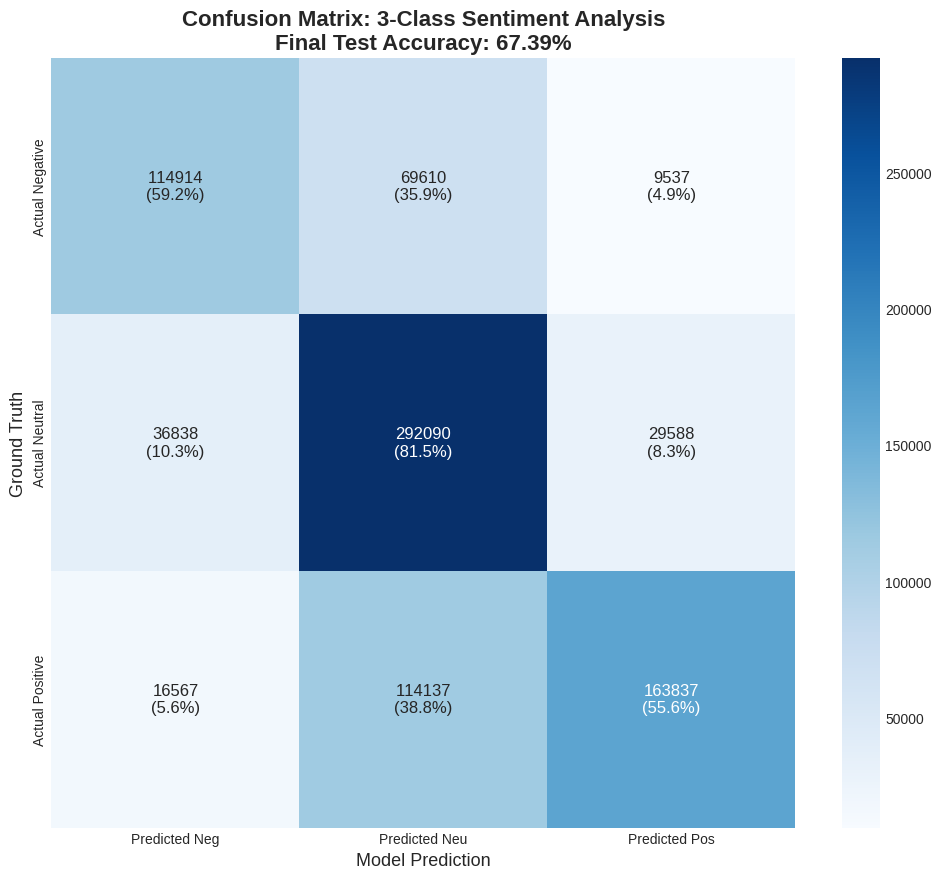

✅ Evaluation complete. Metrics saved to 'final_confusion_matrix_3class.png'.


In [42]:
##for Multiclass classification [0,1,2]
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Classification Report - UPDATED FOR 3 CLASSES
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT (3-CLASS)")
print("="*50)

# We now include 'Neutral' in the target names
# Ensure the order matches your mapping: 0=Neg, 1=Neu, 2=Pos
print(classification_report(test_labels, test_preds, 
                            target_names=['Negative', 'Neutral', 'Positive'], 
                            zero_division=0))

# 2. Confusion Matrix with Percentages
cm = confusion_matrix(test_labels, test_preds)

# Calculate percentages for the heatmap cells (Recall per class)
# We use a small epsilon or np.errstate to avoid division by zero errors
with np.errstate(divide='ignore', invalid='ignore'):
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_perc = np.nan_to_num(cm_perc)

# Create annotations combining count and percentage
# CRITICAL: Reshaped to (3, 3) to match our 3 classes
labels = (np.array(["{0:d}\n({1:.1%})".format(count, perc) 
          for count, perc in zip(cm.flatten(), cm_perc.flatten())]
          )).reshape(3, 3)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=labels, fmt="", cmap='Blues', annot_kws={"size": 12},
            xticklabels=['Predicted Neg', 'Predicted Neu', 'Predicted Pos'], 
            yticklabels=['Actual Negative', 'Actual Neutral', 'Actual Positive'])

plt.title(f'Confusion Matrix: 3-Class Sentiment Analysis\nFinal Test Accuracy: {test_acc:.2%}', 
          fontsize=16, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=13)
plt.xlabel('Model Prediction', fontsize=13)

# Save the plot before showing
plt.savefig('final_confusion_matrix_3class.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Evaluation complete. Metrics saved to 'final_confusion_matrix_3class.png'.")